In [1]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([
	T.ToImage(), 
	T.ToDtype(torch.float32, scale=True)
])

train_and_valid_data = torchvision.datasets.FashionMNIST(
	root='./data', 
	train=True, 
	download=True,
	transform=toTensor
	)
test_data = torchvision.datasets.FashionMNIST(
	root='./data', 
	train=False, 
	download=True,
	transform=toTensor
	)

train_data, valid_data = torch.utils.data.random_split(train_and_valid_data, [0.9, 0.1])
print(len(train_data), len(valid_data), len(test_data))
# from torch.utils.data import TensorDataset
# test_data = TensorDataset(test_data.data, test_data.targets)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

54000 6000 10000


In [3]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cpu'

In [4]:
def train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs):
	history = {
		'loss' : [],
		'train_metric' : [],
		'valid_metric' : [],
	}
	for epoch in range(n_epochs):
		# Training 
		total_loss = 0
		metric.reset()
		for X_batch, y_batch in train_loader:
			X_batch, y_batch = X_batch.to(device), y_batch.to(device)
			model.train()
			y_pred = model(X_batch)
			loss = criterion(y_pred, y_batch)
			total_loss += loss.item()
			loss.backward()
			optimizer.step()
			# for group in optimizer.param_groups:
			# 	for p in group['params']:
			# 		if p.grad is not None:
			# 			print(f'\t{p.grad.max()}') 
			optimizer.zero_grad()
			metric.update(y_pred, y_batch)
		
		avg_loss = total_loss / len(train_loader)
		history['loss'].append(avg_loss)

		avg_metric_train = metric.compute().item()
		history['train_metric'].append(avg_metric_train)

		# Evaluation 
		model.eval()
		metric.reset()
		with torch.no_grad():
			for X_batch, y_batch in valid_loader:
				X_batch, y_batch = X_batch.to(device), y_batch.to(device)
				y_pred = model(X_batch)
				metric.update(y_pred, y_batch)

		avg_metric_valid = metric.compute().item()
		history['valid_metric'].append(avg_metric_valid)

		print(
			f'Epoch: {epoch+1}/{n_epochs}, '
			+f'Loss: {round(avg_loss,3)}, '
			+f'Train Metric: {round(avg_metric_train,3)}, ' 
			+f'Valid Metric: {round(avg_metric_valid,3)}'
		)

		# if epoch>=2:
		# 	break
	return history

def plot_history(history, n_epochs):
    plt.plot(np.arange(n_epochs) + 1, history['train_metric'], linestyle='--', color='r', marker='.', label='Train')
    plt.plot(np.arange(n_epochs) + 1, history['valid_metric'], linestyle='--', color='b', marker='.', label='Valid')
    plt.legend()
    plt.grid()
    plt.xlabel('Epochs')
    plt.ylabel(f'{metric.__class__.__name__}')
    plt.show()

Epoch: 1/20, Loss: 1.143, Train Metric: 0.613, Valid Metric: 0.745
Epoch: 2/20, Loss: 0.61, Train Metric: 0.78, Valid Metric: 0.801
Epoch: 3/20, Loss: 0.526, Train Metric: 0.815, Valid Metric: 0.813
Epoch: 4/20, Loss: 0.487, Train Metric: 0.829, Valid Metric: 0.827
Epoch: 5/20, Loss: 0.464, Train Metric: 0.836, Valid Metric: 0.823
Epoch: 6/20, Loss: 0.447, Train Metric: 0.842, Valid Metric: 0.823
Epoch: 7/20, Loss: 0.434, Train Metric: 0.847, Valid Metric: 0.828
Epoch: 8/20, Loss: 0.423, Train Metric: 0.852, Valid Metric: 0.837
Epoch: 9/20, Loss: 0.412, Train Metric: 0.855, Valid Metric: 0.846
Epoch: 10/20, Loss: 0.403, Train Metric: 0.859, Valid Metric: 0.847
Epoch: 11/20, Loss: 0.395, Train Metric: 0.862, Valid Metric: 0.85
Epoch: 12/20, Loss: 0.388, Train Metric: 0.864, Valid Metric: 0.847
Epoch: 13/20, Loss: 0.382, Train Metric: 0.866, Valid Metric: 0.857
Epoch: 14/20, Loss: 0.374, Train Metric: 0.868, Valid Metric: 0.859
Epoch: 15/20, Loss: 0.369, Train Metric: 0.871, Valid Metric

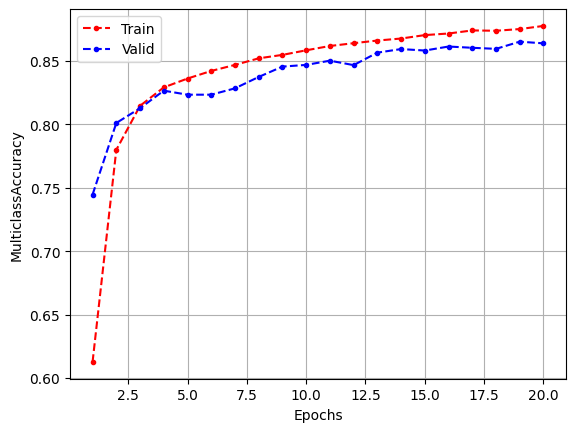

In [5]:
learning_rate = 0.01
n_epochs=20

model = nn.Sequential(
	nn.Flatten(),
	nn.Linear(in_features=1*28*28, out_features=30), 
	nn.LeakyReLU(),
	nn.Linear(in_features=30, out_features=50), 
	nn.LeakyReLU(),
	nn.Linear(in_features=50, out_features=10)
)
# class ImageClassifier(nn.Module):
# 	def __init__(self, n_features, n_classes):
# 		super().__init__()
# 		self.stack = nn.Sequential(
# 			nn.Flatten(),
# 			nn.Linear(in_features=n_features, out_features=30), 
# 			nn.LeakyReLU(),
# 			nn.Linear(in_features=30, out_features=50), 
# 			nn.LeakyReLU(),
# 			nn.Linear(in_features=50, out_features=n_classes)
# 		)
        
# 	def forward(self, X):
# 		y = self.stack(X)
# 		return y
# model = ImageClassifier(n_features=1*28*28, n_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.Accuracy(task='multiclass', num_classes=10).to(device)

history = train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs)
plot_history(history, n_epochs)

In [12]:
model.eval()
metric.reset()
# with torch.no_grad():
with torch.inference_mode():
	for X_batch, y_batch in test_loader:
		X_batch, y_batch = X_batch.to(device), y_batch.to(device)
		y_pred_logits = model(X_batch)
		y_pred = y_pred_logits.argmax(dim=1)
		metric.update(y_pred_logits, y_batch)
avg_metric_test = metric.compute().item()
print(f'Test Metric: {round(avg_metric_test,3)}')

Test Metric: 0.856


In [13]:
model.eval()

X_new, y_new = next(iter(test_loader))
X_new, y_new = X_new.to(device), y_new.to(device)

with torch.inference_mode():
	y_pred_logits = model(X_new)
	y_pred = y_pred_logits.argmax(dim=1)

y_pred[:5]

tensor([9, 2, 1, 1, 6])

In [14]:
[test_data.classes[c] for c in y_pred][:5]

['Ankle boot', 'Pullover', 'Trouser', 'Trouser', 'Shirt']

In [15]:
import torch.nn.functional as F
y_proba = F.softmax(y_pred_logits, dim=1).round(decimals=3)
y_proba[:5]

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0310, 0.0000, 0.0320, 0.0020,
         0.9350],
        [0.0010, 0.0000, 0.9430, 0.0000, 0.0040, 0.0000, 0.0520, 0.0000, 0.0000,
         0.0000],
        [0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.1000, 0.0000, 0.1260, 0.0080, 0.0160, 0.0000, 0.7490, 0.0000, 0.0010,
         0.0000]])

In [16]:
y_top4_values, y_top4_indices = torch.topk(y_pred_logits, k=3, dim=1)
y_top4_values[:5], y_top4_indices[:5]

(tensor([[ 7.9021,  4.5214,  4.4809],
         [13.9483, 11.0580,  8.4276],
         [14.8807,  5.3794,  4.7953],
         [13.1232,  5.1655,  3.5976],
         [ 7.4434,  5.6613,  5.4262]]),
 tensor([[9, 7, 5],
         [2, 6, 4],
         [1, 0, 3],
         [1, 3, 0],
         [6, 2, 0]]))

In [17]:
sum([param.numel() for param in model.parameters()])

25610